**nama anggota kelompok:**

-Rinda aditiya(24523194)
-Aura Dwika Medriana(24523174)

# 1. Pemilihan Dataset
Langkah pertama adalah memuat dataset. Kami menggunakan Dataset Iris dari sklearn.datasets. Dataset ini memiliki 4 fitur (sepal length, sepal width, petal length, petal width) dan 1 target label (spesies).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Memuat data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Dataset berhasil dimuat dengan 4 fitur dan 1 label.")

Dataset berhasil dimuat dengan 4 fitur dan 1 label.


# 2. Preprocessing & Pembagian Data
Data perlu dibagi menjadi data latih untuk membangun model dan data uji untuk mengetes seberapa akurat model kita nanti.
data dibagi menjadi dua bagian: Data Latih (70%) untuk membangun model dan Data Uji (30%) untuk menguji performa model. Penggunaan random_state=42 bertujuan agar hasil pembagian data tetap konsisten setiap kali kode dijalankan.

In [ ]:
# Membagi data: 70% latih, 30% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 105
Jumlah data uji: 45


# 3. Klasifikasi dengan Decision Tree
Algoritma ini bekerja dengan memecah data berdasarkan aturan keputusan (IF-THEN) yang divisualisasikan dalam bentuk pohon.  

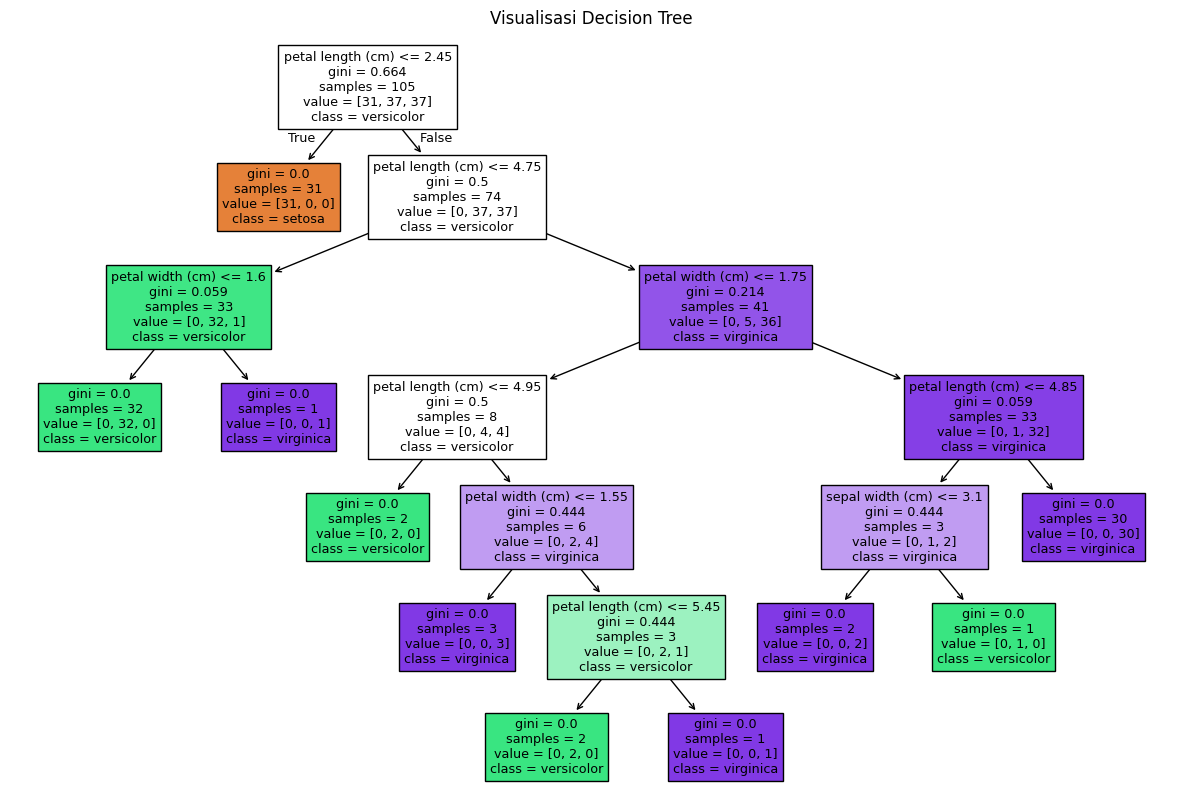

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Membangun model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Visualisasi Pohon Keputusan
plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Visualisasi Decision Tree")
plt.show()

# 4. Klasifikasi dengan Random Forest

model Random Forest dengan 100 pohon (n_estimators=100). Selain itu, kami melakukan eksperimen dengan mengubah nilai n_estimators (10, 50, 100) untuk melihat pengaruh jumlah pohon terhadap tingkat akurasi model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Membangun model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dibangun.")

# Kode untuk Analisis
print("\nEksperimen Pengaruh n_estimators:")
for n in [10, 50, 100]:
    temp_rf = RandomForestClassifier(n_estimators=n, random_state=42)
    temp_rf.fit(X_train, y_train)
    print(f"n_estimators: {n} -> Akurasi: {temp_rf.score(X_test, y_test)}")

Model Random Forest berhasil dibangun.

Eksperimen Pengaruh n_estimators:
n_estimators: 10 -> Akurasi: 1.0
n_estimators: 50 -> Akurasi: 1.0
n_estimators: 100 -> Akurasi: 1.0


# 5. Evaluasi dan Perbandingan
evaluasi menggunakan Accuracy Score, Classification Report, dan Confusion Matrix. Confusion Matrix membantu kami melihat berapa banyak data yang berhasil diprediksi dengan benar (diagonal) dan apakah ada data yang salah diklasifikasikan.


--- Evaluasi Model: Decision Tree ---
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



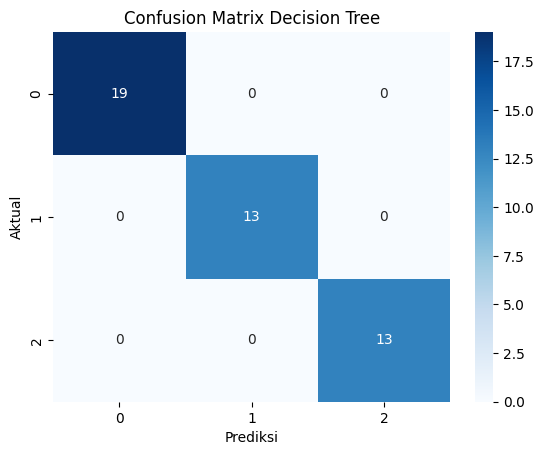


--- Evaluasi Model: Random Forest ---
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



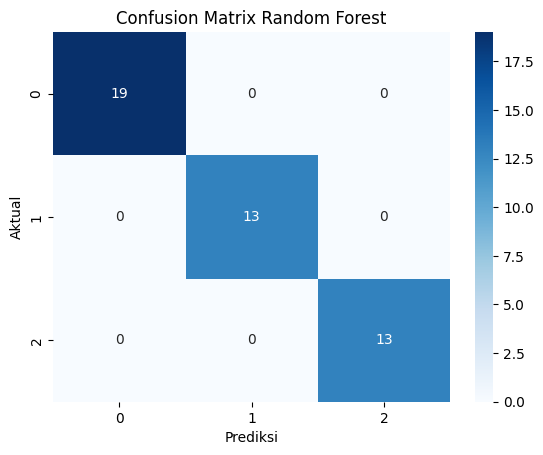

Akurasi Training DT: 1.0
Akurasi Testing DT: 1.0


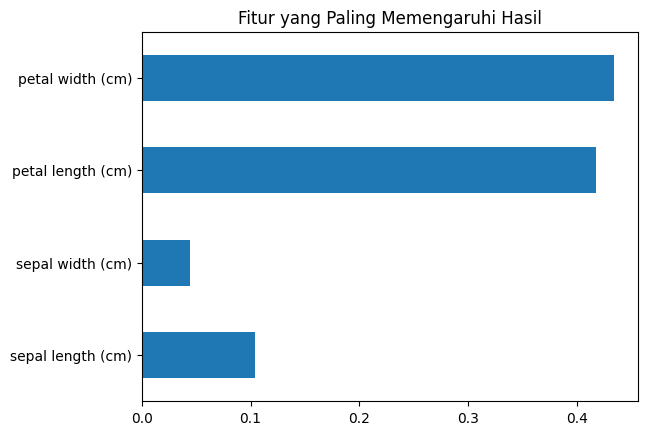

In [ ]:
def evaluasi_model(model, name):
    y_pred = model.predict(X_test)
    print(f"\n--- Evaluasi Model: {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

    # Heatmap Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'Confusion Matrix {name}')
    plt.show()

evaluasi_model(dt_model, "Decision Tree")
evaluasi_model(rf_model, "Random Forest")

print(f"Akurasi Training DT: {dt_model.score(X_train, y_train)}")
print(f"Akurasi Testing DT: {dt_model.score(X_test, y_test)}")

importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names)
importances.plot(kind='barh', title='Fitur yang Paling Memengaruhi Hasil')
plt.show()

# **ANALISIS**

1. Secara angka akurasi, kedua model sama-sama mencapai 100%. Namun, Random Forest lebih diunggulkan untuk penggunaan jangka panjang. Karena menggunakan sistem ensemble (banyak pohon), Random Forest jauh lebih stabil dan tidak mudah "kaget" atau berubah hasilnya jika ada sedikit variasi pada data baru dibandingkan Decision Tree yang hanya mengandalkan satu pohon.

2. Decision Tree: Keunggulannya sangat mudah dipahami alur logikanya secara visual. Namun, kelemahannya adalah mudah mengalami overfitting dan kurang stabil jika data berubah.

   Random Forest: Keunggulannya jauh lebih tangguh terhadap data yang berantakan (noise) dan lebih akurat. Kekurangannya adalah prosesnya lebih berat (memakan memori) dan sulit dijelaskan alur keputusannya secara sederhana karena melibatkan banyak pohon.

3. Ada indikasi overfitting pada Decision Tree. Model ini cenderung menghafal data latih hingga detail terkecil agar akurasinya sempurna. Pada dataset Iris yang skalanya kecil, model sering membuat aturan yang terlalu spesifik, sehingga ada risiko performanya menurun jika bertemu data bunga yang karakteristiknya sedikit berbeda dari data latihan.

4. Fitur sangat menentukan arah percabangan dalam model. Berdasarkan visualisasi, Petal Width dan Petal Length (mahkota bunga) adalah fitur yang paling krusial. Kedua fitur ini biasanya muncul di bagian paling atas pohon, yang artinya ukuran mahkota bunga adalah penentu utama jenis spesies Iris, jauh lebih berpengaruh daripada ukuran kelopaknya (Sepal).

# **Jawaban :**

1. Apa perbedaan mendasar antara Decision Tree dan Random Forest?
Perbedaan utamanya terletak pada jumlah model yang digunakan. Decision Tree adalah model tunggal yang bekerja dengan satu diagram alir keputusan untuk mencapai prediksi. Sementara itu, Random Forest adalah kumpulan dari banyak Decision Tree yang bekerja secara bersama-sama (ensemble). Keputusan akhir pada Random Forest diambil berdasarkan hasil voting terbanyak dari seluruh pohon yang ada di dalamnya, sehingga hasilnya lebih stabil dan akurat.

2. Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?
Decision Tree rentan overfitting karena algoritmanya cenderung tumbuh sangat dalam dan kompleks demi mengklasifikasikan setiap detail data latih dengan sempurna. Akibatnya, model seringkali "menghafal" data alih-alih mempelajari pola umumnya. Random Forest mengatasi hal ini dengan cara menggabungkan prediksi dari banyak pohon yang berbeda. Karena setiap pohon dilatih dengan sampel data yang berbeda, kesalahan atau overfitting pada satu pohon tertentu akan diredam oleh hasil dari pohon-pohon lainnya.

3. Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?

   Bagging (Bootstrap Aggregating): Berfungsi untuk memberikan sampel data yang berbeda secara acak kepada setiap pohon. Hal ini memastikan bahwa setiap pohon tidak mempelajari data yang identik, sehingga varians model berkurang dan hasil akhir lebih objektif.

   Pemilihan Subset Fitur Acak: Berfungsi untuk memastikan bahwa setiap percabangan pohon hanya memilih fitur dari kelompok acak, bukan dari seluruh fitur yang ada. Tujuannya adalah agar antar pohon tidak berkorelasi satu sama lain dan model dipaksa untuk mencari pola dari berbagai sudut pandang fitur yang berbeda.

4. Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?
Decision Tree lebih cocok digunakan ketika prioritas utama kita adalah kemudahan interpretasi dan transparansi. Jika kita perlu menjelaskan alur logika pengambilan keputusan secara visual dan sederhana kepada orang awam (misalnya dalam kebijakan medis atau hukum), Decision Tree jauh lebih praktis. Selain itu, untuk dataset yang sangat kecil dan sederhana, Decision Tree lebih efisien karena proses komputasinya jauh lebih cepat dan ringan dibandingkan Random Forest.